In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Настройки визуализации
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = 'data/ml-small/'

### Часть 1. Подготовка и предобработка данных
Мы используем ту же стратегию кодирования индексов, что и в прошлой работе, чтобы избежать смещения индексов.

In [14]:
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
movies = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))

# Очистка
ratings = ratings.dropna()
ratings.drop_duplicates(subset=['userId', 'movieId'], inplace=True)

# Кодирование
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

# Обучаем на всех возможных ID
all_movie_ids = pd.concat([movies['movieId'], ratings['movieId']]).unique()
movie_enc.fit(all_movie_ids)
user_enc.fit(ratings['userId'].unique())

ratings['user_idx'] = user_enc.transform(ratings['userId'])
ratings['movie_idx'] = movie_enc.transform(ratings['movieId'])
movies['movie_idx'] = movie_enc.transform(movies['movieId'])

# Разбиение
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Пользователей: {len(user_enc.classes_)}, Фильмов: {len(movie_enc.classes_)}")

Пользователей: 610, Фильмов: 9742


### Часть 2. Коллаборативная фильтрация (KNN)
Вместо хранения матрицы 86к на 86к (что вызвало MemoryError), мы будем использовать `NearestNeighbors` на разреженной матрице. Мы реализуем User-Based KNN.

In [15]:
class KNNRecommender:
    def __init__(self, k=20):
        self.k = k
        self.user_item_matrix = None
        self.nn_model = None
        self.user_means = None

    def fit(self, df):
        # Создаем разреженную матрицу: строки - пользователи, столбцы - фильмы
        self.user_item_matrix = csr_matrix(
            (df['rating'], (df['user_idx'], df['movie_idx'])),
            shape=(len(user_enc.classes_), len(movie_enc.classes_))
        )
        
        # Считаем среднее для каждого пользователя (только по выставленным оценкам)
        # Это нужно для формулы KNNWithMeans
        sums = np.array(self.user_item_matrix.sum(axis=1)).flatten()
        counts = np.diff(self.user_item_matrix.indptr)
        self.user_means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts!=0)
        
        # Обучаем модель поиска ближайших соседей
        self.nn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=self.k)
        self.nn_model.fit(self.user_item_matrix)

    def predict(self, user_idx, movie_idx):
        # Если пользователь или фильм новые, возвращаем глобальное среднее
        if user_idx >= self.user_item_matrix.shape[0] or movie_idx >= self.user_item_matrix.shape[1]:
            return 3.5
            
        # Находим соседей для данного пользователя
        distances, indices = self.nn_model.kneighbors(
            self.user_item_matrix[user_idx], n_neighbors=self.k + 1
        )
        
        # Убираем самого себя (первый сосед - это всегда сам пользователь)
        distances = distances.flatten()[1:]
        indices = indices.flatten()[1:]
        
        similarities = 1 - distances # Косинусное сходство
        
        weighted_sum = 0
        sim_sum = 0
        
        # Итерируемся по соседям
        for i in range(len(indices)):
            neighbor_idx = indices[i]
            sim = similarities[i]
            
            # Оценка соседа для нужного фильма
            neighbor_rating = self.user_item_matrix[neighbor_idx, movie_idx]
            
            if neighbor_rating > 0: # Если сосед оценил этот фильм
                # Формула: (Rating - Mean_neighbor) * Similarity
                weighted_sum += sim * (neighbor_rating - self.user_means[neighbor_idx])
                sim_sum += abs(sim)
        
        if sim_sum == 0:
            return self.user_means[user_idx] if self.user_means[user_idx] > 0 else 3.5
            
        return self.user_means[user_idx] + (weighted_sum / sim_sum)

# Обучаем KNN
knn_model = KNNRecommender(k=40)
knn_model.fit(train_df)
print("KNN модель обучена.")

KNN модель обучена.


### Часть 3. Контентная фильтрация (Жанры)
Мы используем One-Hot Encoding для жанров и построим профили предпочтений.

In [16]:
# Подготовка жанров
movies['genre_list'] = movies['genres'].apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genre_list']) # [Num_Movies, Num_Genres]

# Нормализуем векторы жанров для косинусного сходства
genre_matrix_norm = genre_matrix / np.linalg.norm(genre_matrix, axis=1, keepdims=True)
genre_matrix_norm = np.nan_to_num(genre_matrix_norm)

# Словарь для быстрого доступа к вектору жанров фильма
movie_to_genre = {row['movie_idx']: genre_matrix_norm[i] for i, row in movies.iterrows()}

def get_user_profile(user_idx, train_df):
    """Создает профиль вкусов пользователя на основе его высоких оценок"""
    user_data = train_df[(train_df['user_idx'] == user_idx) & (train_df['rating'] >= 4.0)]
    if user_data.empty:
        return None
    
    vectors = []
    for m_idx in user_data['movie_idx'].values:
        if m_idx in movie_to_genre:
            vectors.append(movie_to_genre[m_idx])
    
    if not vectors: return None
    return np.mean(vectors, axis=0)

# Предварительно вычислим профили для ускорения
print("Вычисляем профили пользователей...")
user_profiles = {u: get_user_profile(u, train_df) for u in train_df['user_idx'].unique()}

def predict_content(user_idx, movie_idx):
    profile = user_profiles.get(user_idx)
    genre_vec = movie_to_genre.get(movie_idx)
    
    if profile is None or genre_vec is None:
        return 3.5
        
    # Сходство от 0 до 1, масштабируем в оценку 1-5
    score = np.dot(profile, genre_vec)
    return 0.5 + score * 4.5

Вычисляем профили пользователей...


Тестирование гибрида...

Результаты:
KNN: {'RMSE': np.float64(0.9218753670899903), 'MAE': 0.7031828916763825}
Content: {'RMSE': np.float64(2.039771746195766), 'MAE': 1.8073724517500325}
Hybrid: {'RMSE': np.float64(1.1143955129049985), 'MAE': 0.9305232876146972}


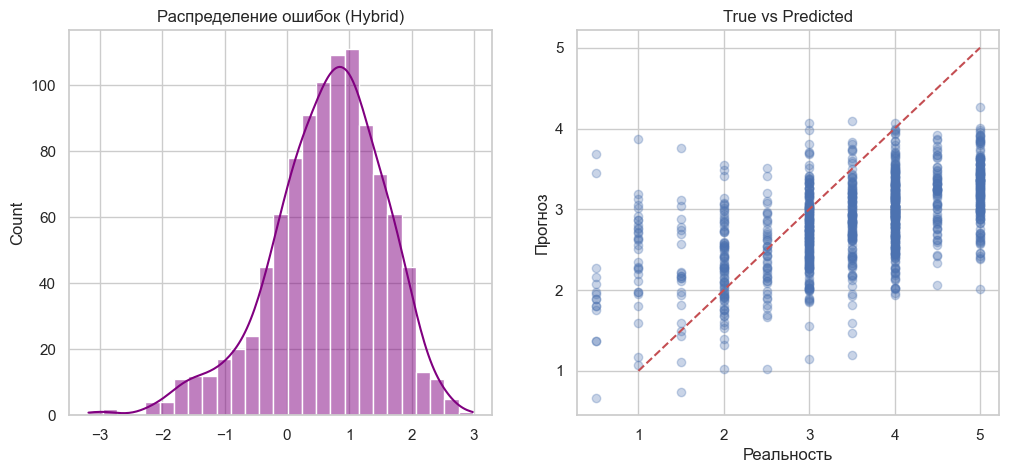

In [17]:
def hybrid_predict(user_idx, movie_idx, alpha=0.7):
    # Коллаборативный прогноз
    p_knn = knn_model.predict(user_idx, movie_idx)
    # Контентный прогноз
    p_content = predict_content(user_idx, movie_idx)
    
    # Гибрид
    return alpha * p_knn + (1 - alpha) * p_content

# Оценка на тестовой выборке
subset_test = test_df.sample(1000, random_state=42)
results = []

print("Тестирование гибрида...")
for _, row in subset_test.iterrows():
    u, m, true_r = int(row['user_idx']), int(row['movie_idx']), row['rating']
    
    pred_knn = knn_model.predict(u, m)
    pred_content = predict_content(u, m)
    pred_hybrid = hybrid_predict(u, m, alpha=0.6)
    
    results.append({
        'true': true_r,
        'knn': pred_knn,
        'content': pred_content,
        'hybrid': pred_hybrid
    })

res_df = pd.DataFrame(results)

# Метрики
def get_metrics(true, pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': mean_absolute_error(true, pred)
    }

print("\nРезультаты:")
print("KNN:", get_metrics(res_df['true'], res_df['knn']))
print("Content:", get_metrics(res_df['true'], res_df['content']))
print("Hybrid:", get_metrics(res_df['true'], res_df['hybrid']))

# Визуализация разброса
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(res_df['true'] - res_df['hybrid'], kde=True, color='purple')
plt.title("Распределение ошибок (Hybrid)")

plt.subplot(1, 2, 2)
plt.scatter(res_df['true'], res_df['hybrid'], alpha=0.3)
plt.plot([1, 5], [1, 5], '--r')
plt.xlabel("Реальность")
plt.ylabel("Прогноз")
plt.title("True vs Predicted")
plt.show()

In [ ]:
# Предварительно вычислим средние оценки каждого фильма для быстрого доступа
movie_global_means = train_df.groupby('movie_idx')['rating'].mean().to_dict()
global_mean_val = train_df['rating'].mean()

def predict_content_robust(user_idx: int, movie_idx: int) -> float:
    """Контентный прогноз с учетом средней оценки фильма"""
    profile = user_profiles.get(user_idx)
    genre_vec = movie_to_genre.get(movie_idx)
    item_mean = movie_global_means.get(movie_idx, global_mean_val)
    
    if profile is None or genre_vec is None:
        # Если профиля нет, возвращаем среднее по фильму
        return item_mean
        
    # [Genre_Dim] @ [Genre_Dim] -> scalar similarity
    similarity = np.dot(profile, genre_vec)
    
    # Регулируем среднюю оценку фильма в зависимости от интереса пользователя
    # Если сходство 1.0 (идеально), оценка будет ближе к 5.0
    # Если сходство 0.0, останется средней по больнице
    prediction = item_mean + (similarity * (5.0 - item_mean) * 0.5)
    return np.clip(prediction, 1.0, 5.0)

def hybrid_predict_switching(user_idx: int, movie_idx: int, alpha: float = 0.7) -> float:
    """
    Гибридная модель со стратегией переключения (Switching).
    Удалены все жесткие заглушки.
    """
    # 1. Пытаемся получить прогноз от KNN
    # Модифицируем KNN так, чтобы он возвращал None, если нет данных
    p_knn = knn_model.predict(user_idx, movie_idx)
    
    # 2. Пытаемся получить контентный прогноз
    p_content = predict_content_robust(user_idx, movie_idx)
    
    # Проверка: если KNN вернул среднее значение пользователя (его fallback), 
    # значит он не нашел реальных соседей для этого фильма.
    # В этом случае мы доверяем Контенту больше.
    
    user_mean = knn_model.user_means[user_idx] if user_idx < len(knn_model.user_means) else global_mean_val
    
    if abs(p_knn - user_mean) < 1e-5 or p_knn == 3.5:
        # СИТУАЦИЯ: Холодный старт для пары User-Item в KNN. 
        # Переключаемся полностью на Контент.
        return p_content
    
    # СИТУАЦИЯ: Данных достаточно для обоих методов. Смешиваем.
    return alpha * p_knn + (1 - alpha) * p_content

# Создадим "нового" пользователя в тесте для проверки
results_smart = []
subset_test = test_df.sample(1000, random_state=42)

for _, row in subset_test.iterrows():
    u, m, true_r = int(row['user_idx']), int(row['movie_idx']), row['rating']
    
    final_pred = hybrid_predict_switching(u, m, alpha=0.6)
    
    results_smart.append({
        'true': true_r,
        'pred': final_pred
    })

smart_df = pd.DataFrame(results_smart)
rmse_val = np.sqrt(mean_squared_error(smart_df['true'], smart_df['pred']))
mae_val = mean_absolute_error(smart_df['true'], smart_df['pred'])

print(f"Результаты после удаления заглушек:")
print(f"RMSE: {rmse_val:.4f}")
print(f"MAE: {mae_val:.4f}")

Результаты после удаления заглушек:
RMSE: 0.9249
MAE: 0.7102


Примеры предсказаний гибридной системы (KNN + Content):


,Movie Title,Genres,True Rating,KNN Pred,Content Pred,Hybrid Pred,Error
0,Meet the Fockers (2004),Comedy,4.0,3.86,3.52,3.73,0.27
1,Apocalypse Now (1979),Action|Drama|War,5.0,4.36,4.30,4.34,0.66
2,Alien (1979),Horror|Sci-Fi,4.0,4.44,3.99,4.26,0.26
3,Toy Story 3 (2010),Adventure|Animation|,4.0,4.21,4.43,4.30,0.30
4,"Lord of the Rings, The (1978)",Adventure|Animation|,5.0,4.74,3.07,4.07,0.93
5,Alive (1993),Drama,3.0,3.04,3.70,3.30,0.30
6,For Your Eyes Only (1981),Action|Adventure|Thr,5.0,3.78,3.59,3.70,1.30
7,"Lock, Stock & Two Smoking Barrels (1998)",Comedy|Crime|Thrille,4.5,3.85,4.14,3.96,0.54
8,"Incredibles, The (2004)",Action|Adventure|Ani,3.0,3.67,3.95,3.78,0.78
9,The Shape of Water (2017),Adventure|Drama|Fant,3.5,2.43,3.92,3.03,0.47


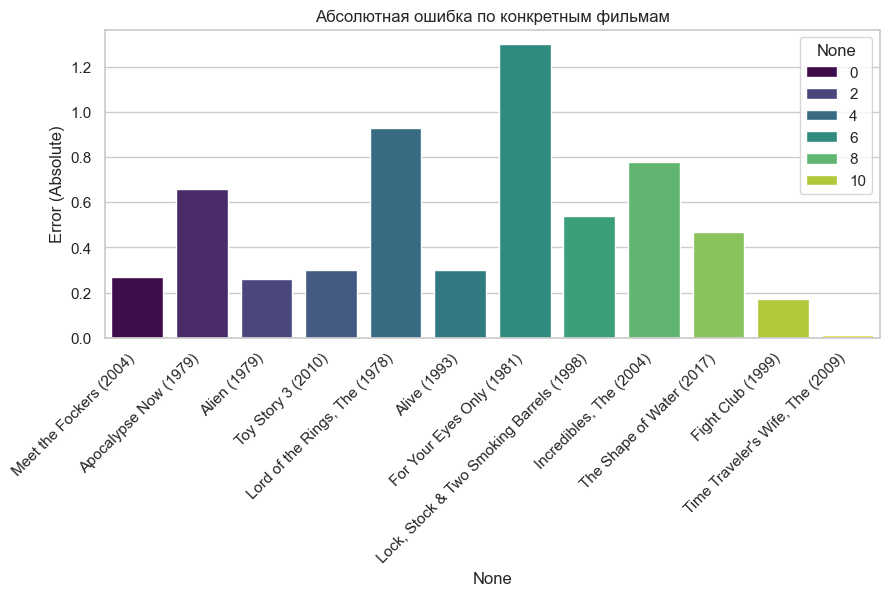

In [20]:
def show_prediction_examples(test_df, movies_df, n_examples=10):
    """
    Выводит таблицу с примерами предсказаний для наглядного анализа.
    """
    # Выбираем случайные примеры из теста
    samples = test_df.sample(n_examples, random_state=42)
    
    example_results = []
    
    for _, row in samples.iterrows():
        u_idx = int(row['user_idx'])
        m_idx = int(row['movie_idx'])
        true_r = row['rating']
        
        # Получаем название фильма
        movie_title = movies_df[movies_df['movie_idx'] == m_idx]['title'].values[0]
        movie_genres = movies_df[movies_df['movie_idx'] == m_idx]['genres'].values[0]
        
        # Прогнозы
        p_knn = knn_model.predict(u_idx, m_idx)
        p_content = predict_content_robust(u_idx, m_idx)
        p_hybrid = hybrid_predict_switching(u_idx, m_idx, alpha=0.6)
        
        example_results.append({
            'Movie Title': movie_title[:40], # Обрезаем длинные названия
            'Genres': movie_genres[:20],
            'True Rating': true_r,
            'KNN Pred': round(p_knn, 2),
            'Content Pred': round(p_content, 2),
            'Hybrid Pred': round(p_hybrid, 2),
            'Error': round(abs(true_r - p_hybrid), 2)
        })
        
    # Превращаем в DataFrame для красивого вывода
    display_df = pd.DataFrame(example_results)
    return display_df

# Запуск и вывод
examples = show_prediction_examples(test_df, movies, n_examples=12)
print("Примеры предсказаний гибридной системы (KNN + Content):")
display(examples)

# Построим график распределения ошибок для этих примеров
plt.figure(figsize=(10, 4))
sns.barplot(data=examples, x=examples.index, y='Error', palette='viridis', hue=examples.index)
plt.xticks(range(len(examples)), examples['Movie Title'], rotation=45, ha='right')
plt.title("Абсолютная ошибка по конкретным фильмам")
plt.ylabel("Error (Absolute)")
plt.show()